# Calibrate H5 File Workflow

Run HDF5 calibration and inspect the fitted per-channel timing/lifetime outputs.


In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from brighteyes_mcs_file import calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts
import brighteyes_mcs_file.graph as graph


In [2]:
Path.cwd().resolve()

PosixPath('/home/mdonato/myDev/BrightEyes-MCS-File/examples')

## Calibration Parameters


In [3]:
DATA_KEY = ('data', 'data_channels_extra')
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]

FILE_REFERENCE = '/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5'
FILE_DATA = '/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/03_Convallaria_DFD_40MHz-17-03-2026-17-07-20_calib.h5'

TAU_REF = 2.5
REFERENCE_TYPE = 'ref'
FIT_MODE = 'model_shift'
FIT_TYPE = 'likelihood'
LASER_PERIOD_NS = None

CHANNEL_SKEW_TYPE = "phase_cross_correlation"
CHANNEL_SKEW_SOURCE = 'ref'
CHANNEL_SKEW_FIT_REFERENCE_CHANNEL = 12
CHANNEL_SKEW_FIT_UPSAMPLING = 10
CHANNEL_SKEW_FIT_APODIZE = False
OVERWRITE = True


## Run Calibration


In [4]:
output_path = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type=CHANNEL_SKEW_TYPE,
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=CHANNEL_SKEW_FIT_REFERENCE_CHANNEL,
    channel_skew_fit_upsampling=CHANNEL_SKEW_FIT_UPSAMPLING,
    channel_skew_fit_apodize=CHANNEL_SKEW_FIT_APODIZE,
    period_ns=LASER_PERIOD_NS,
    overwrite=OVERWRITE,
)
print(output_path)


Calibrating data keys:   0%|          | 0/2 [00:00<?, ?key/s]

Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

Calibrating data_channels_extra:   0%|          | 0/2 [00:00<?, ?ch/s]

/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/03_Convallaria_DFD_40MHz-17-03-2026-17-07-20_calib_calib.h5


/home/mdonato/myDev/BrightEyes-MCS-File/src/brighteyes_mcs_file/h5_data_calibrator.py:1413: RuntimeWarning: Skipping calibration for data key 'data_channels_extra', channel 0: data histogram has a non-positive or non-finite sum
  ).calibrate()


## Load Calibration Tables


In [5]:
def get_calibration_group(hf, data_key=INSPECT_DATA_KEY, calibration_key="calibration"):
    calibration_root = hf[calibration_key]
    if data_key not in calibration_root or not isinstance(calibration_root[data_key], h5py.Group):
        raise KeyError(f"Expected group {calibration_key}/{data_key}; available: {list(calibration_root.keys())}")
    return calibration_root[data_key]


def calibration_summary_dataframe(group):
    return pd.DataFrame(
        {
            "channel": group["channel_index"][()],
            "channel_used_for_reference_in_time_skew": group["channel_used_for_reference_in_time_skew"][()],
            "fit_param_C": group["fit_param_C"][()],
            "fit_param_C_err": group["fit_param_C_err"][()],
            "tau_ns": group["tau_ns"][()],
            "tau_err_ns": group["tau_err_ns"][()],
            "tau_ref_ns": group["tau_ref_ns"][()],
            "fit_common_delay_in_bins": group["fit_common_delay_in_bins"][()],
            "fit_common_delay_in_ns": group["fit_common_delay_in_ns"][()],
            "common_delay_in_bins": group["common_delay_in_bins"][()],
            "fit_common_delay_err_in_bins": group["fit_common_delay_err_in_bins"][()],
            "common_delay_in_ns": group["common_delay_in_ns"][()],
            "fit_common_delay_err_in_ns": group["fit_common_delay_err_in_ns"][()],
            "channel_skew": group["channel_skew"][()],
            "channel_skew_est_err": group["channel_skew_est_err"][()],
            "fit_error": group["fit_error"][()],
        }
    )

with h5py.File(output_path, "r") as hf:
    calibration = get_calibration_group(hf)
    summary_df = calibration_summary_dataframe(calibration)
    attrs = dict(calibration.attrs)

summary_df


,channel,channel_used_for_reference_in_time_skew,fit_param_C,fit_param_C_err,tau_ns,tau_err_ns,tau_ref_ns,common_delay_in_bins,fit_common_delay_err_in_bins,common_delay_in_ns,fit_common_delay_err_in_ns,channel_skew,channel_skew_est_err,fit_error
0,0,0,1.0,0.000587,1.866209,0.001387,2.5,-4.207430,0.002745,-1.155887,0.000754,0.344143,NaN,0.002800
1,1,1,1.0,0.000550,1.872188,0.001277,2.5,-4.170332,0.002440,-1.145696,0.000670,-1.405282,NaN,0.002718
2,2,2,1.0,0.000541,1.901201,0.001253,2.5,-4.161206,0.002342,-1.143188,0.000643,-1.544012,NaN,0.002740
3,3,3,1.0,0.000568,1.934812,0.001327,2.5,-4.113454,0.002333,-1.130070,0.000641,0.289811,NaN,0.002678
4,4,4,1.0,0.000617,1.992450,0.001481,2.5,-4.148490,0.002729,-1.139695,0.000750,-0.218801,NaN,0.002689
5,5,5,1.0,0.000535,1.861954,0.001201,2.5,-4.106754,0.002139,-1.128229,0.000588,-0.133714,NaN,0.002711
6,6,6,1.0,0.000475,1.808335,0.001059,2.5,-4.168317,0.002056,-1.145142,0.000565,-0.119358,NaN,0.002844
7,7,7,1.0,0.000474,1.818680,0.001057,2.5,-4.121364,0.001985,-1.132243,0.000545,-0.487073,NaN,0.002736
8,8,8,1.0,0.000503,1.890324,0.001140,2.5,-4.073976,0.001921,-1.119224,0.000528,-0.522411,NaN,0.002763
9,9,9,1.0,0.000577,1.952913,0.001370,2.5,-4.117090,0.002451,-1.131069,0.000673,0.067237,NaN,0.002540


## Channel Fit Summary


(<Figure size 1200x600 with 4 Axes>,
 (<Axes: title={'center': 'Calibration lifetime by channel'}, ylabel='Lifetime (ns)'>,
  <Axes: title={'center': 'Lifetime distribution'}, xlabel='Channel count'>,
  <Axes: xlabel='Channel', ylabel='Fit RMSE'>))

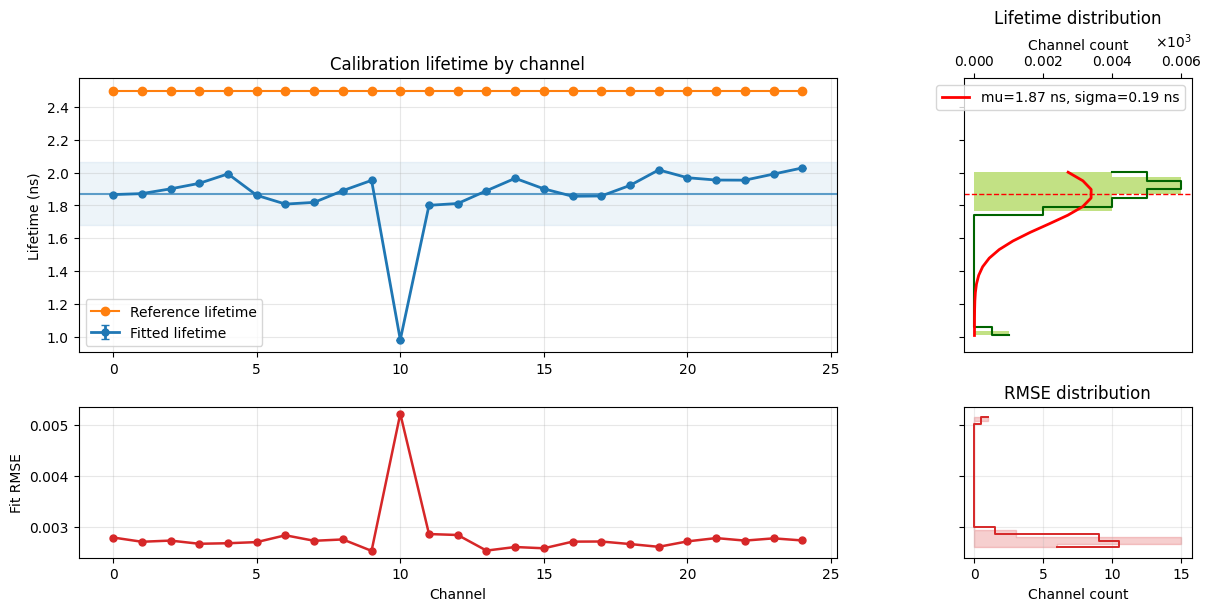

In [6]:
graph.plot_calibration_lifetime_summary(summary_df)


(<Figure size 1600x640 with 4 Axes>,
 (<Axes: title={'center': 'Channel skew'}, ylabel='Channel skew (bins)'>,
  <Axes: title={'center': 'Fitted common delay'}, xlabel='Channel', ylabel='Common delay (ns)'>))

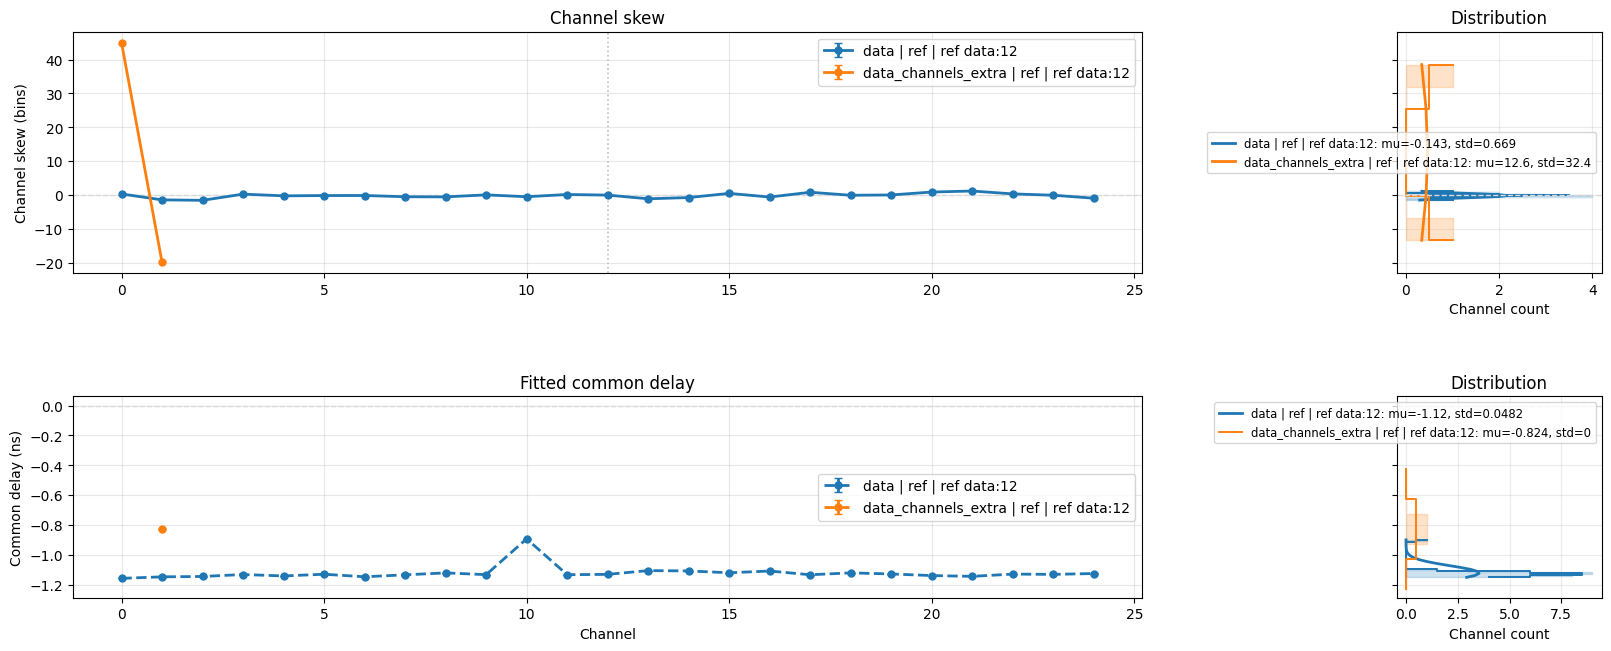

In [7]:
data_keys = [DATA_KEY] if isinstance(DATA_KEY, str) else list(DATA_KEY)
summary_tables = []
labels = []
with h5py.File(output_path, "r") as hf:
    for data_key in data_keys:
        group = get_calibration_group(hf, data_key=data_key)
        summary_tables.append(calibration_summary_dataframe(group))
        source = group.attrs.get("channel_skew_source", "not stored")
        ref_key = group.attrs.get("channel_skew_fit_reference_data_key", data_key)
        ref_channel = group.attrs.get("channel_skew_fit_reference_channel_resolved", CHANNEL_SKEW_FIT_REFERENCE_CHANNEL)
        labels.append(f"{data_key} | {source} | ref {ref_key}:{ref_channel}")

graph.plot_calibration_shift_summary(
    summary_tables,
    labels=labels,
    reference_channel=CHANNEL_SKEW_FIT_REFERENCE_CHANNEL,
)


## Inspect One Channel Fit


<Axes: title={'center': 'Channel 12: tau=1.81 ns, delay=-1.13 ns, RMSE=0.00285'}, xlabel='Time (ns)', ylabel='Normalized counts'>

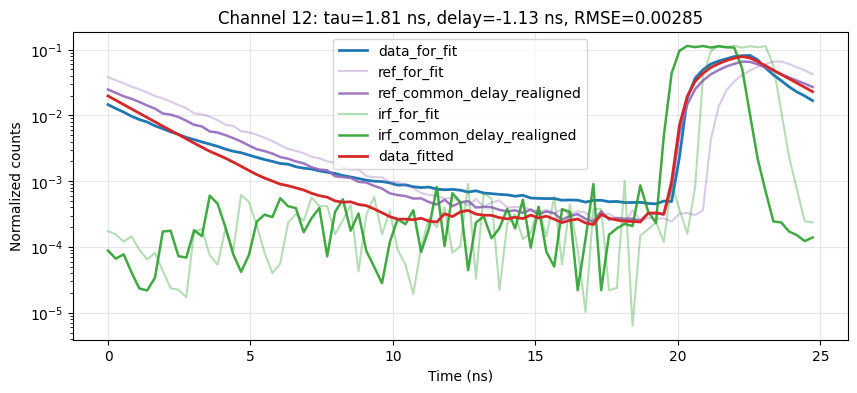

In [8]:
CHANNEL = 12

with h5py.File(output_path, "r") as hf:
    calibration = get_calibration_group(hf)
    calibrated_channels = calibration["channel_index"][()]
    column = int(np.where(calibrated_channels == CHANNEL)[0][0])
    laser_period_in_ns = float(calibration.attrs["laser_period_in_ns"])
    t_ns = np.arange(calibration["data_for_fit"].shape[0], dtype=float) * laser_period_in_ns / calibration["data_for_fit"].shape[0]

    traces = {
        "data_for_fit": calibration["data_for_fit"][:, column],
        "ref_for_fit": calibration["ref_for_fit"][:, column] if "ref_for_fit" in calibration else None,
        "ref_common_delay_realigned": calibration["ref_common_delay_realigned"][:, column] if "ref_common_delay_realigned" in calibration else None,
        "irf_for_fit": calibration["irf_for_fit"][:, column],
        "irf_common_delay_realigned": calibration["irf_common_delay_realigned"][:, column],
        "data_fitted": calibration["data_fitted"][:, column],
    }
    tau_ns = float(calibration["tau_ns"][column])
    delay_ns = float(calibration["common_delay_in_ns"][column])
    fit_error = float(calibration["fit_error"][column])

fig, ax = plt.subplots(figsize=(10, 4))
graph.plot_calibration_fit_traces(
    t_ns,
    traces,
    title=f"Channel {CHANNEL}: tau={tau_ns:.2f} ns, delay={delay_ns:.2f} ns, RMSE={fit_error:.3g}",
    ax=ax,
)


## HDF5 Structure


In [9]:
show_h5_structure_html(output_path)


'<div class="h5-tree">\n  <style>\n    .h5-tree {\n      color-scheme: light dark;\n      font-family: "Menlo", "Consolas", "DejaVu Sans Mono", monospace;\n      font-size: 13px;\n      line-height: 1.5;\n      color: var(--h5-fg);\n      --h5-fg: #1f2937;\n      --h5-muted: #6b7280;\n      --h5-border: #d1d5db;\n      --h5-group: #0f766e;\n      --h5-dataset: #1d4ed8;\n      --h5-attrs: #7c2d12;\n      --h5-node-ref: #7c3aed;\n      --h5-attr-key: #b45309;\n      --h5-attr-value: #374151;\n      --h5-root: #111827;\n    }\n    @media (prefers-color-scheme: dark) {\n      .h5-tree {\n        --h5-fg: #e5e7eb;\n        --h5-muted: #9ca3af;\n        --h5-border: #4b5563;\n        --h5-group: #5eead4;\n        --h5-dataset: #93c5fd;\n        --h5-attrs: #fdba74;\n        --h5-node-ref: #c4b5fd;\n        --h5-attr-key: #fbbf24;\n        --h5-attr-value: #f3f4f6;\n        --h5-root: #f9fafb;\n      }\n    }\n    .h5-tree ul {\n      list-style: none;\n      margin: 0.2rem 0 0.2rem 1.1rem;\n

In [10]:
output_path


'/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/03_Convallaria_DFD_40MHz-17-03-2026-17-07-20_calib_calib.h5'